In [ ]:
!pip install yfinance pandas numpy matplotlib seaborn pyarrow -q

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/PRISM'
PATHS = {
    'raw'     : f'{BASE_PATH}/raw',
    'features': f'{BASE_PATH}/features',
    'splits'  : f'{BASE_PATH}/splits',
    'plots'   : f'{BASE_PATH}/plots',
    'models'  : f'{BASE_PATH}/models',
    'results' : f'{BASE_PATH}/results'
}

for path in PATHS.values():
    os.makedirs(path, exist_ok=True)

print("Directory structure ready:")
for k, v in PATHS.items():
    print(f"  {k:10s} -> {v}")

Mounted at /content/drive
Directory structure ready:
  raw        -> /content/drive/MyDrive/PRISM/raw
  features   -> /content/drive/MyDrive/PRISM/features
  splits     -> /content/drive/MyDrive/PRISM/splits
  plots      -> /content/drive/MyDrive/PRISM/plots
  models     -> /content/drive/MyDrive/PRISM/models
  results    -> /content/drive/MyDrive/PRISM/results


In [ ]:
CONFIG = {
    'tickers'      : ['XLK', 'XLE', 'XLV', 'XLF', 'XLU',
                      'XLI', 'XLP', 'XLY', 'SPY'],
    'start_date'   : '2008-01-01',
    'end_date'     : '2023-12-31',
    'roll_short'   : 20,
    'roll_long'    : 60,
    'splits': {
        'train'  : ('2008-01-01', '2017-12-31'),
        'val'    : ('2018-01-01', '2018-12-31'),
        'test1'  : ('2019-01-01', '2019-12-31'),
        'test2'  : ('2020-01-01', '2021-12-31'),
        'test3'  : ('2022-01-01', '2023-12-31')
    }
}

print("Configuration loaded:")
print(f"  Tickers     : {CONFIG['tickers']}")
print(f"  Date range  : {CONFIG['start_date']} to {CONFIG['end_date']}")
print(f"  Splits      : {list(CONFIG['splits'].keys())}")

Configuration loaded:
  Tickers     : ['XLK', 'XLE', 'XLV', 'XLF', 'XLU', 'XLI', 'XLP', 'XLY', 'SPY']
  Date range  : 2008-01-01 to 2023-12-31
  Splits      : ['train', 'val', 'test1', 'test2', 'test3']


In [ ]:
print(f"Downloading data for {len(CONFIG['tickers'])} assets...")
print(f"Date range: {CONFIG['start_date']} to {CONFIG['end_date']}\n")

raw = yf.download(
    CONFIG['tickers'],
    start=CONFIG['start_date'],
    end=CONFIG['end_date'],
    auto_adjust=True,
    progress=True
)

close  = raw['Close']
volume = raw['Volume']
high   = raw['High']
low    = raw['Low']
open_  = raw['Open']

print(f"\n--- RAW DATA SUMMARY ---")
print(f"Shape          : {close.shape}")
print(f"Date range     : {close.index[0].date()} to {close.index[-1].date()}")
print(f"Trading days   : {len(close)}")
print(f"Assets         : {list(close.columns)}")

print(f"\n--- FIRST 5 ROWS ---")
print(close.head())

print(f"\n--- LAST 5 ROWS ---")
print(close.tail())

print(f"\n--- MISSING VALUES ---")
missing = close.isnull().sum()
print(missing)
print(f"\nTotal missing: {missing.sum()}")

close.to_parquet(f"{PATHS['raw']}/close.parquet")
volume.to_parquet(f"{PATHS['raw']}/volume.parquet")
print(f"\nRaw data saved to {PATHS['raw']}")

Date range: 2008-01-01 to 2023-12-31



[*********************100%***********************]  9 of 9 completed



--- RAW DATA SUMMARY ---
Shape          : (4027, 9)
Date range     : 2008-01-02 to 2023-12-29
Trading days   : 4027
Assets         : ['SPY', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']

--- FIRST 5 ROWS ---
Ticker             SPY        XLE        XLF        XLI        XLK        XLP  \
Date                                                                            
2008-01-02  103.495605  22.563316  16.207541  27.002884  10.229499  17.380112   
2008-01-03  103.445633  22.830101  16.104670  27.023924  10.245165  17.288279   
2008-01-04  100.910522  21.995682  15.647470  26.469984   9.845696  17.214815   
2008-01-07  100.824860  21.910534  15.687477  26.140423   9.759540  17.416842   
2008-01-08   99.196709  21.527390  15.115980  25.558443   9.501057  17.288279   

Ticker            XLU        XLV        XLY  
Date                                         
2008-01-02  11.105027  25.450977  12.765076  
2008-01-03  11.089192  25.603949  12.622362  
2008-01-04  11.173625  25.34

In [ ]:
print("=== DATA QUALITY REPORT ===\n")

# Check 1: Missing values
print("1. Missing Values")
missing = close.isnull().sum()
if missing.sum() == 0:
    print("   PASS — No missing values found\n")
else:
    print(f"   WARNING — Missing values detected:\n{missing[missing > 0]}\n")
    close = close.fillna(method='ffill').fillna(method='bfill')
    print("   Applied forward/backward fill\n")

# Check 2: Date alignment
print("2. Date Alignment")
for ticker in CONFIG['tickers']:
    if close[ticker].isnull().sum() == 0:
        print(f"   {ticker}: OK ({len(close[ticker])} days)")

# Check 3: Zero or negative prices
print("\n3. Zero / Negative Prices")
zero_prices = (close <= 0).sum()
if zero_prices.sum() == 0:
    print("   PASS — No zero or negative prices\n")
else:
    print(f"   WARNING:\n{zero_prices[zero_prices > 0]}\n")

# Check 4: Extreme daily moves (> 50% in a day)
returns_check = close.pct_change()
extreme = (returns_check.abs() > 0.5).sum()
if extreme.sum() == 0:
    print("4. Extreme Returns Check")
    print("   PASS — No returns exceeding 50% in a single day\n")
else:
    print(f"4. Extreme Returns Check")
    print(f"   WARNING — Extreme returns detected:\n{extreme[extreme > 0]}\n")

print("=== QUALITY CHECK COMPLETE ===")

=== DATA QUALITY REPORT ===

1. Missing Values
   PASS — No missing values found

2. Date Alignment
   XLK: OK (4027 days)
   XLE: OK (4027 days)
   XLV: OK (4027 days)
   XLF: OK (4027 days)
   XLU: OK (4027 days)
   XLI: OK (4027 days)
   XLP: OK (4027 days)
   XLY: OK (4027 days)
   SPY: OK (4027 days)

3. Zero / Negative Prices
   PASS — No zero or negative prices

4. Extreme Returns Check
   PASS — No returns exceeding 50% in a single day

=== QUALITY CHECK COMPLETE ===


In [ ]:
print("Engineering features...\n")

rs  = CONFIG['roll_short']  # 20
rl  = CONFIG['roll_long']   # 60

# --- Returns ---
log_returns = np.log(close / close.shift(1))

# --- Rolling Volatility ---
vol_20 = log_returns.rolling(rs).std()
vol_60 = log_returns.rolling(rl).std()

# --- Momentum ---
mom_20 = close.pct_change(rs)
mom_60 = close.pct_change(rl)

# --- Volume Ratio ---
vol_ratio = volume / volume.rolling(rs).mean()

# --- Rolling Correlation to SPY (market beta proxy) ---
spy_corr_20 = log_returns.rolling(rs).corr(log_returns['SPY'])

# --- Build Feature Matrix ---
feature_frames = []

for ticker in CONFIG['tickers']:
    df = pd.DataFrame({
        f'{ticker}_return'   : log_returns[ticker],
        f'{ticker}_vol20'    : vol_20[ticker],
        f'{ticker}_vol60'    : vol_60[ticker],
        f'{ticker}_mom20'    : mom_20[ticker],
        f'{ticker}_mom60'    : mom_60[ticker],
        f'{ticker}_volratio' : vol_ratio[ticker],
        f'{ticker}_spycorr'  : spy_corr_20[ticker],
    })
    feature_frames.append(df)

features = pd.concat(feature_frames, axis=1)
features = features.dropna()

print(f"--- FEATURE MATRIX ---")
print(f"Shape          : {features.shape}")
print(f"Features       : {features.shape[1]}")
print(f"Date range     : {features.index[0].date()} to {features.index[-1].date()}")
print(f"Trading days   : {len(features)}")
print(f"\n--- FIRST 3 ROWS ---")
print(features.iloc[:, :6].head(3))
print(f"\n--- SUMMARY STATISTICS ---")
print(features.describe().round(4).iloc[:, :6])

features.to_parquet(f"{PATHS['features']}/features.parquet")
print(f"\nFeatures saved to {PATHS['features']}/features.parquet")

Engineering features...

--- FEATURE MATRIX ---
Shape          : (3967, 63)
Features       : 63
Date range     : 2008-03-31 to 2023-12-29
Trading days   : 3967

--- FIRST 3 ROWS ---
            XLK_return  XLK_vol20  XLK_vol60  XLK_mom20  XLK_mom60  \
Date                                                                 
2008-03-31   -0.001339   0.018531   0.016217   0.011561  -0.142187   
2008-04-01    0.028605   0.019557   0.016702   0.041385  -0.118645   
2008-04-02    0.012074   0.019684   0.016049   0.052608  -0.071745   

            XLK_volratio  
Date                      
2008-03-31      1.068851  
2008-04-01      1.351323  
2008-04-02      0.653670  

--- SUMMARY STATISTICS ---
       XLK_return  XLK_vol20  XLK_vol60  XLK_mom20  XLK_mom60  XLK_volratio
count   3967.0000  3967.0000  3967.0000  3967.0000  3967.0000     3967.0000
mean       0.0006     0.0125     0.0129     0.0135     0.0393        1.0126
std        0.0146     0.0079     0.0071     0.0549     0.0911        0.4378


In [ ]:
print("Creating train/test splits...\n")

split_summary = []

for name, (start, end) in CONFIG['splits'].items():
    split = features[start:end]
    split.to_parquet(f"{PATHS['splits']}/{name}.parquet")
    split_summary.append({
        'Split'      : name,
        'Start'      : split.index[0].date(),
        'End'        : split.index[-1].date(),
        'Trading Days': len(split),
        'Features'   : split.shape[1]
    })
    print(f"{name:8s} | {split.index[0].date()} to {split.index[-1].date()} | {len(split)} days")

print(f"\nAll splits saved to {PATHS['splits']}")

# Sanity check — confirm no overlap
print("\n--- OVERLAP CHECK ---")
train_idx = set(features['2008':'2017'].index)
for name, (start, end) in CONFIG['splits'].items():
    if name == 'train':
        continue
    test_idx = set(features[start:end].index)
    overlap = train_idx.intersection(test_idx)
    status = "PASS" if len(overlap) == 0 else f"FAIL — {len(overlap)} overlapping days"
    print(f"  train vs {name:6s}: {status}")

Creating train/test splits...

train    | 2008-03-31 to 2017-12-29 | 2458 days
val      | 2018-01-02 to 2018-12-31 | 251 days
test1    | 2019-01-02 to 2019-12-31 | 252 days
test2    | 2020-01-02 to 2021-12-31 | 505 days
test3    | 2022-01-03 to 2023-12-29 | 501 days

All splits saved to /content/drive/MyDrive/PRISM/splits

--- OVERLAP CHECK ---
  train vs val   : PASS
  train vs test1 : PASS
  train vs test2 : PASS
  train vs test3 : PASS


In [ ]:
# Separate clean HMM input — SPY return and volatility only
# This is what the HMM will train on

hmm_input = pd.DataFrame({
    'spy_return' : log_returns['SPY'],
    'spy_vol20'  : vol_20['SPY'],
}, index=log_returns.index).dropna()

hmm_train = hmm_input['2008':'2017']
hmm_full  = hmm_input  # used for full regime labeling

hmm_input.to_parquet(f"{PATHS['features']}/hmm_input.parquet")
hmm_train.to_parquet(f"{PATHS['features']}/hmm_train.parquet")

print(f"HMM input shape (full) : {hmm_input.shape}")
print(f"HMM input shape (train): {hmm_train.shape}")
print(f"\nHMM input preview:")
print(hmm_train.head(10).round(5))
print(f"\nHMM features saved to {PATHS['features']}")

HMM input shape (full) : (4007, 2)
HMM input shape (train): (2498, 2)

HMM input preview:
            spy_return  spy_vol20
Date                             
2008-01-31     0.01807    0.01453
2008-02-01     0.01596    0.01511
2008-02-04    -0.01269    0.01437
2008-02-05    -0.02714    0.01549
2008-02-06    -0.00808    0.01521
2008-02-07     0.00659    0.01507
2008-02-08    -0.00644    0.01495
2008-02-11     0.00510    0.01500
2008-02-12     0.00923    0.01504
2008-02-13     0.01017    0.01452

HMM features saved to /content/drive/MyDrive/PRISM/features


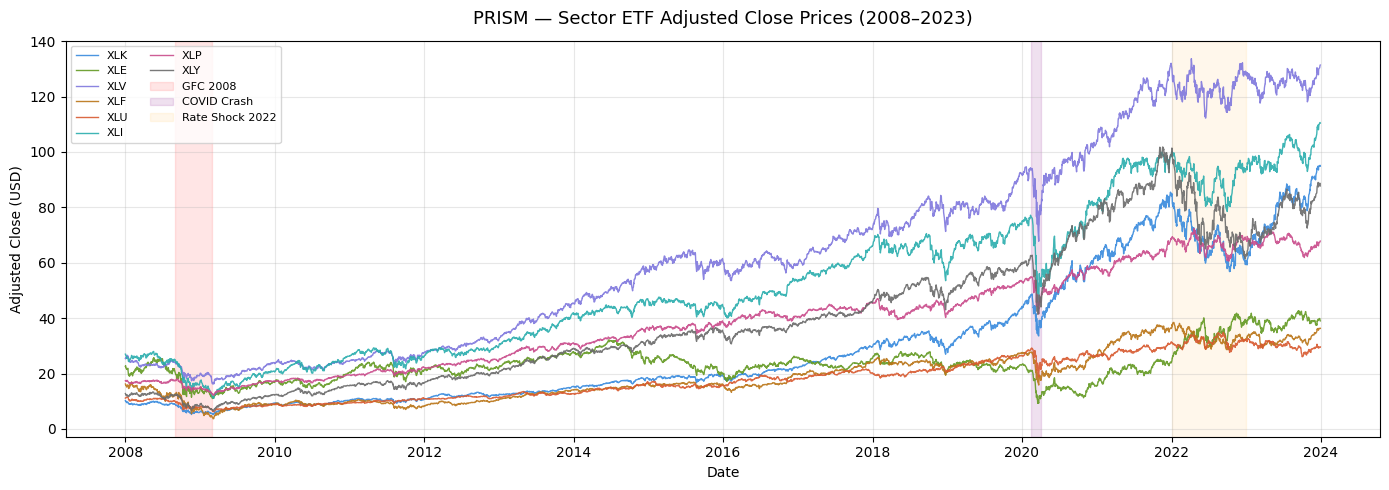

Plot 1 saved


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#378ADD','#639922','#7F77DD','#BA7517','#D85A30',
          '#2AADAD','#C94B8B','#6B6B6B','#000000']

etfs = [t for t in CONFIG['tickers'] if t != 'SPY']
for ticker, color in zip(etfs, colors[:-1]):
    ax.plot(close.index, close[ticker], label=ticker,
            color=color, linewidth=1, alpha=0.9)

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.1, color='red', label='GFC 2008')
ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-01'),
           alpha=0.12, color='purple', label='COVID Crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color='orange', label='Rate Shock 2022')

ax.set_title('PRISM — Sector ETF Adjusted Close Prices (2008–2023)',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close (USD)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/01_prices.png", dpi=150)
plt.show()
print("Plot 1 saved")

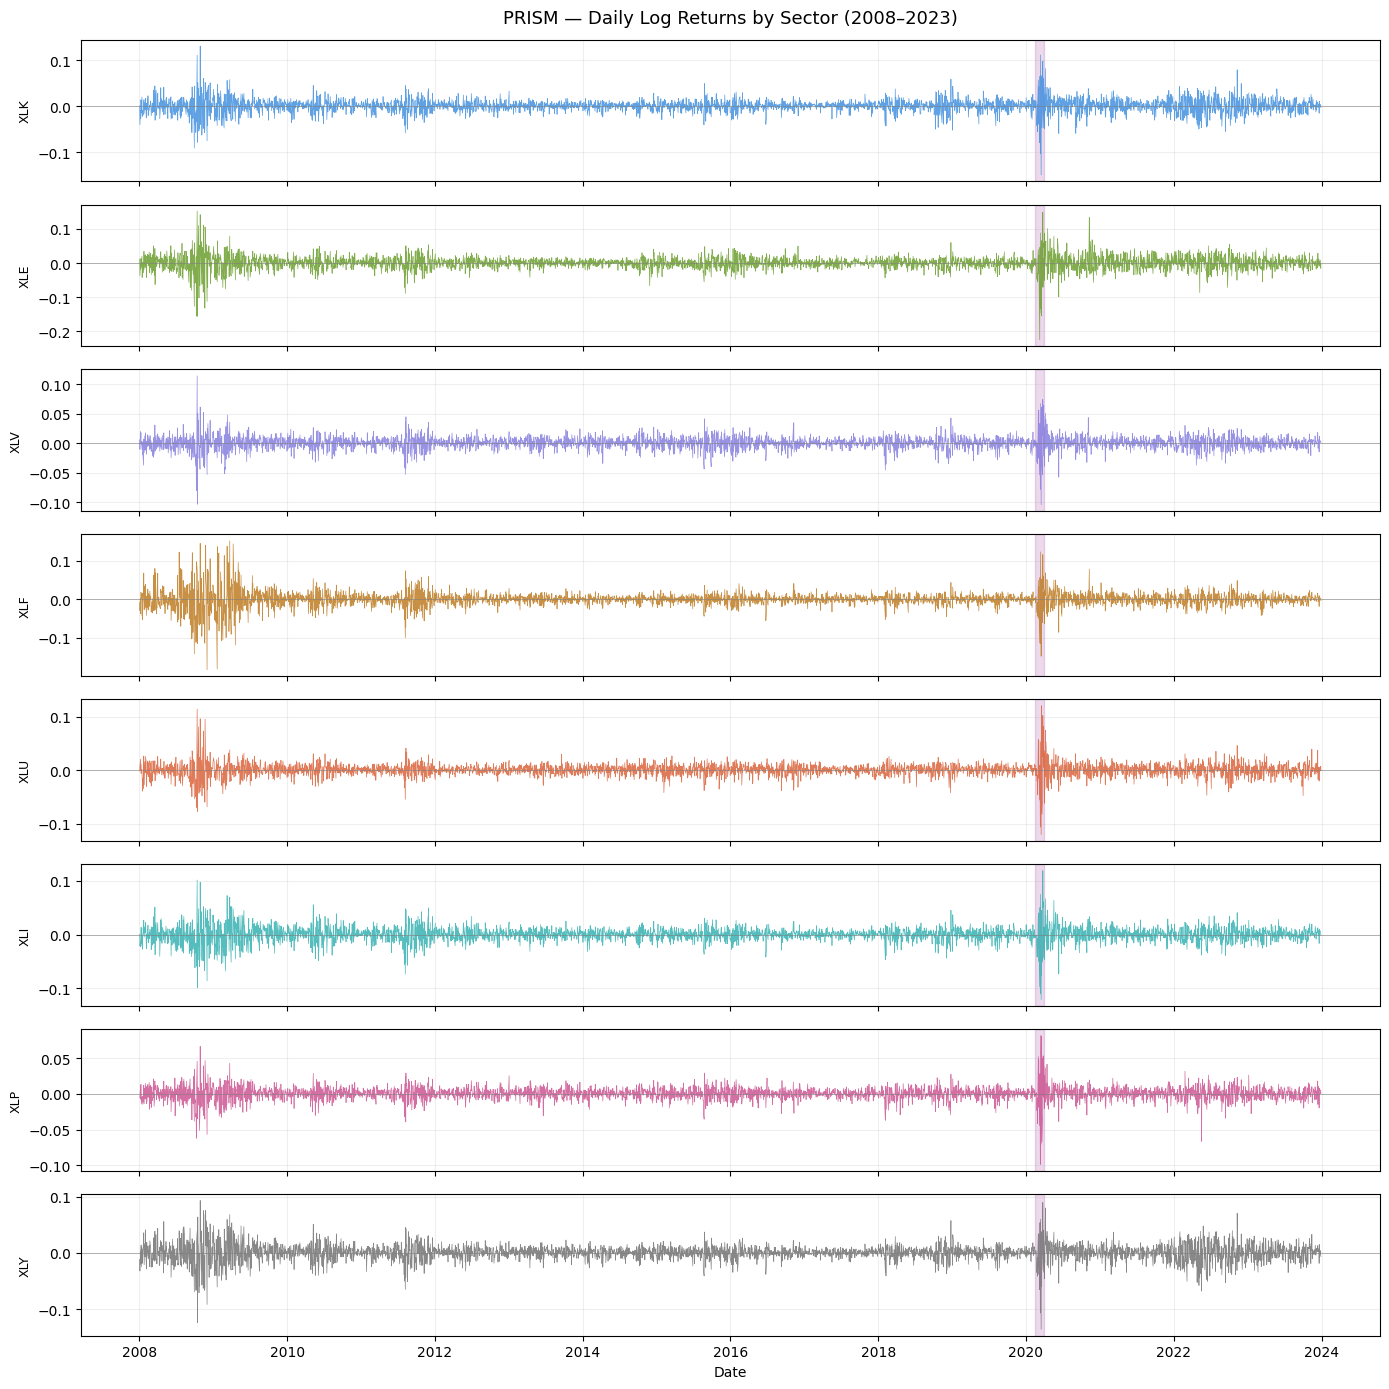

Plot 2 saved


In [ ]:
etfs = [t for t in CONFIG['tickers'] if t != 'SPY']
fig, axes = plt.subplots(len(etfs), 1, figsize=(14, 14), sharex=True)

for i, (ticker, color) in enumerate(zip(etfs, colors[:-1])):
    axes[i].plot(log_returns.index, log_returns[ticker],
                 color=color, linewidth=0.5, alpha=0.8)
    axes[i].axhline(0, color='gray', linewidth=0.4)
    axes[i].set_ylabel(ticker, fontsize=9)
    axes[i].grid(True, alpha=0.2)
    axes[i].axvspan(pd.Timestamp('2020-02-15'),
                    pd.Timestamp('2020-04-01'), alpha=0.15, color='purple')

axes[0].set_title('PRISM — Daily Log Returns by Sector (2008–2023)',
                  fontsize=13, fontweight='500', pad=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/02_log_returns.png", dpi=150)
plt.show()
print("Plot 2 saved")

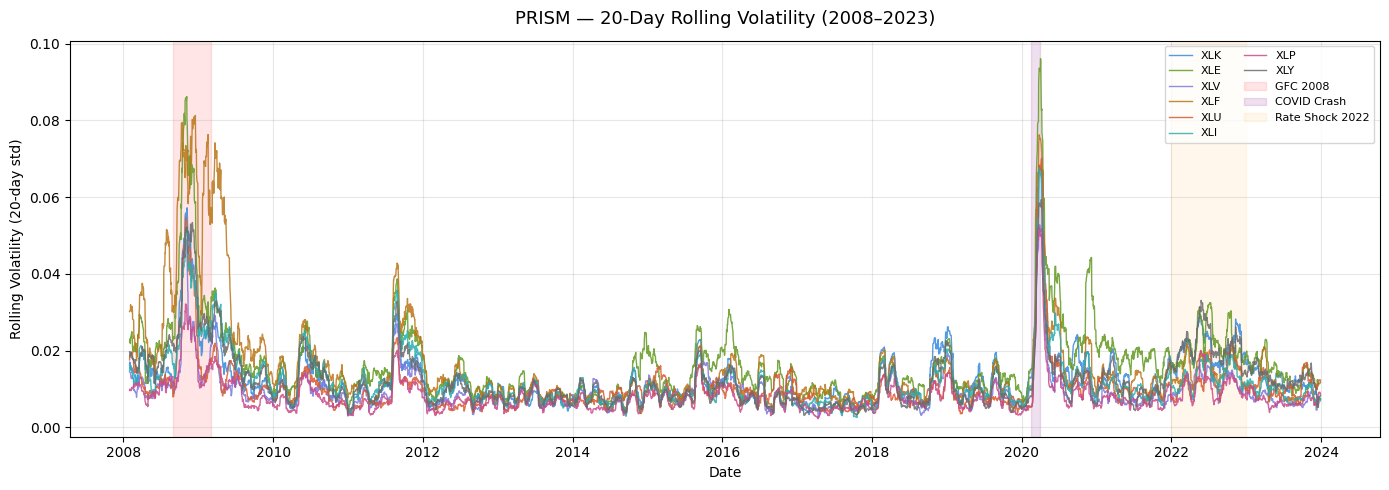

Plot 3 saved


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for ticker, color in zip(etfs, colors[:-1]):
    ax.plot(vol_20.index, vol_20[ticker],
            label=ticker, color=color, linewidth=1, alpha=0.85)

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.1, color='red', label='GFC 2008')
ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-01'),
           alpha=0.12, color='purple', label='COVID Crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color='orange', label='Rate Shock 2022')

ax.set_title('PRISM — 20-Day Rolling Volatility (2008–2023)',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Volatility (20-day std)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/03_volatility.png", dpi=150)
plt.show()
print("Plot 3 saved")

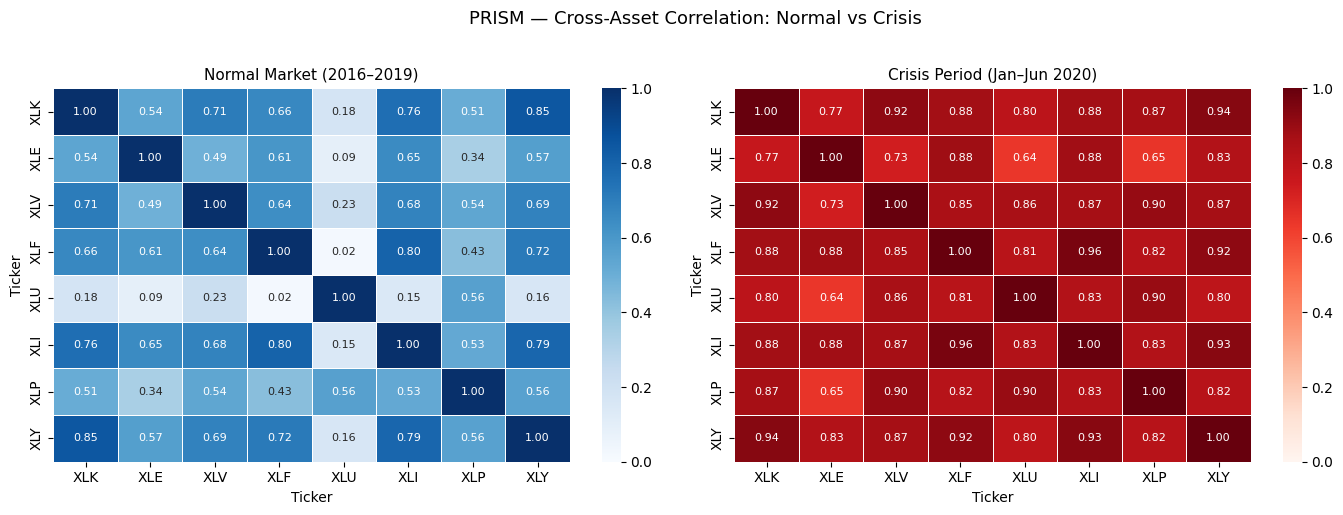

Plot 4 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

periods = {
    'Normal Market (2016–2019)' : ('2016', '2019'),
    'Crisis Period (Jan–Jun 2020)': ('2020-01', '2020-06')
}
cmaps = ['Blues', 'Reds']

for ax, (title, (s, e)), cmap in zip(axes, periods.items(), cmaps):
    corr = log_returns[s:e][etfs].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap,
                ax=ax, vmin=0, vmax=1,
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(title, fontsize=11, fontweight='500')

plt.suptitle('PRISM — Cross-Asset Correlation: Normal vs Crisis',
             fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/04_correlations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved")

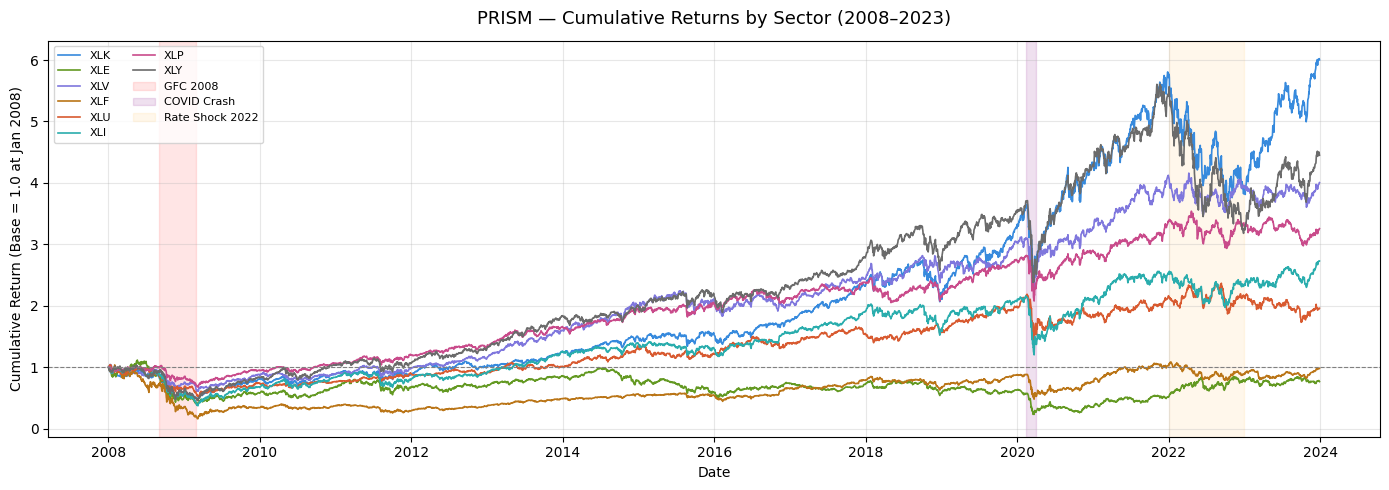

Plot 5 saved


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

cum_returns = (1 + log_returns[etfs]).cumprod()

for ticker, color in zip(etfs, colors[:-1]):
    ax.plot(cum_returns.index, cum_returns[ticker],
            label=ticker, color=color, linewidth=1.2)

ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.1, color='red', label='GFC 2008')
ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-04-01'),
           alpha=0.12, color='purple', label='COVID Crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color='orange', label='Rate Shock 2022')

ax.axhline(1, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('PRISM — Cumulative Returns by Sector (2008–2023)',
             fontsize=13, fontweight='500', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (Base = 1.0 at Jan 2008)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/05_cumulative_returns.png", dpi=150)
plt.show()
print("Plot 5 saved")

In [ ]:
print("=" * 55)
print("   PRISM — DATA PIPELINE COMPLETE")
print("=" * 55)
print(f"\nAssets         : {', '.join(CONFIG['tickers'])}")
print(f"Date range     : {CONFIG['start_date']} to {CONFIG['end_date']}")
print(f"Trading days   : {len(features)}")
print(f"Total features : {features.shape[1]}")
print(f"\nSplits:")
for name, (start, end) in CONFIG['splits'].items():
    split = features[start:end]
    print(f"  {name:8s} | {start} to {end} | {len(split)} days")
print(f"\nFiles saved to Google Drive:")
print(f"  raw/       -> close.parquet, volume.parquet")
print(f"  features/  -> features.parquet, hmm_input.parquet, hmm_train.parquet")
print(f"  splits/    -> train, val, test1, test2, test3 (.parquet)")
print(f"  plots/     -> 01 to 05 (.png)")
print("=" * 55)
print("\nData pipeline frozen. Ready for HMM.")

   PRISM — DATA PIPELINE COMPLETE

Assets         : XLK, XLE, XLV, XLF, XLU, XLI, XLP, XLY, SPY
Date range     : 2008-01-01 to 2023-12-31
Trading days   : 3967
Total features : 63

Splits:
  train    | 2008-01-01 to 2017-12-31 | 2458 days
  val      | 2018-01-01 to 2018-12-31 | 251 days
  test1    | 2019-01-01 to 2019-12-31 | 252 days
  test2    | 2020-01-01 to 2021-12-31 | 505 days
  test3    | 2022-01-01 to 2023-12-31 | 501 days

Files saved to Google Drive:
  raw/       -> close.parquet, volume.parquet
  features/  -> features.parquet, hmm_input.parquet, hmm_train.parquet
  splits/    -> train, val, test1, test2, test3 (.parquet)
  plots/     -> 01 to 05 (.png)

Data pipeline frozen. Ready for HMM.
